# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels, lw=1)

## Simulation $H=0.8$

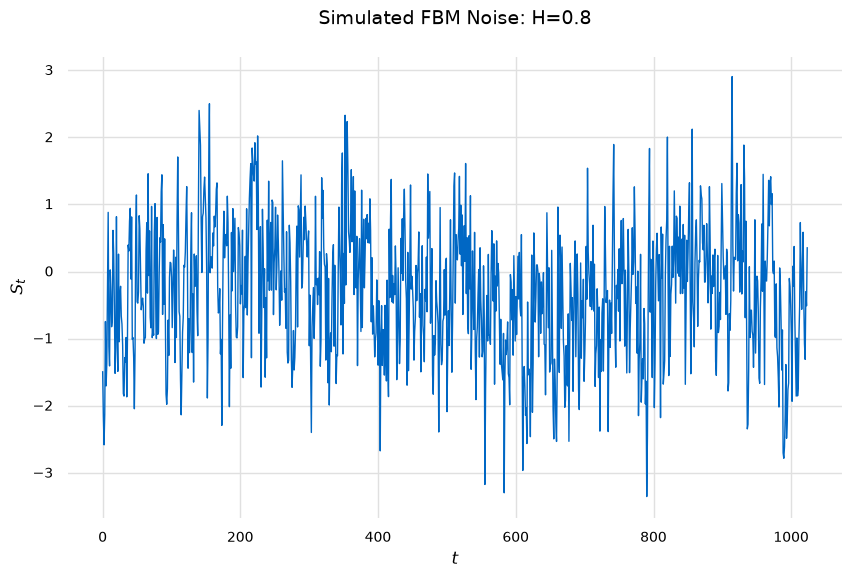

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

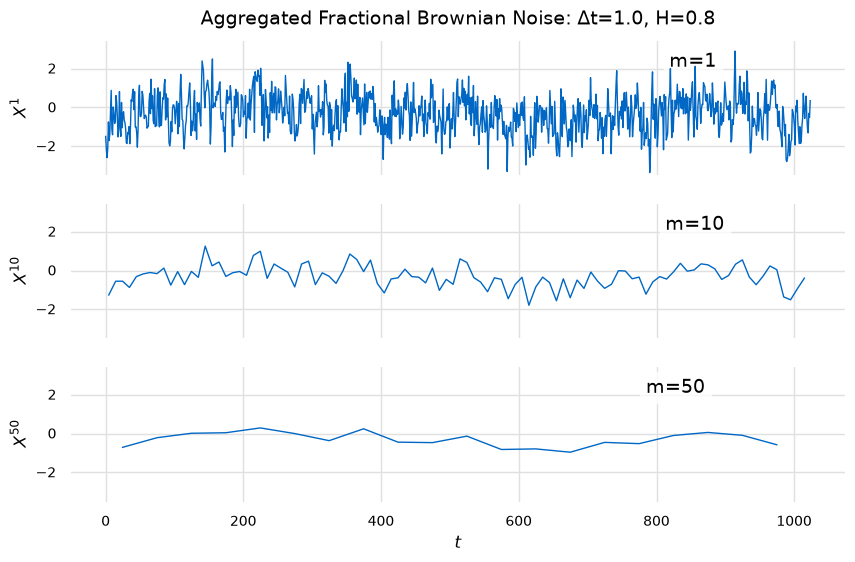

In [4]:
var_agg_comparison(t, fbm_noise, H)

In [5]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [6]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     3785.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           4.08e-80
Time:                        13:39:52   Log-Likelihood:                 195.03
No. Observations:                 100   AIC:                            -386.1
Df Residuals:                      98   BIC:                            -380.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0369      0.014      2.611      0.010       0.009       0.065
x1            -0.5334      0.009    -61.524      0.000      -0.551      -0.516
==============================================================================
Omnibus:                        0.044   Durbin-Watson:                   1.598
Prob(Omnibus):                  0.978   Jarque-Bera (JB):                0.052
Skew:                          -0.037   Prob(JB):                        0.974
Kurtosis:                       2.918   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.03688378660241262,
      "err": 0.014128858108534372,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "062709b6-bb0c-4100-b67a-815adae5e239",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.5333532060071525,
         "err": 0.008669029631231904,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "062709b6-bb0c-4100-b67a-815adae5e239",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9747630827747036,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "062709b6-bb0c-4100-b67a-815adae5e239",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param"

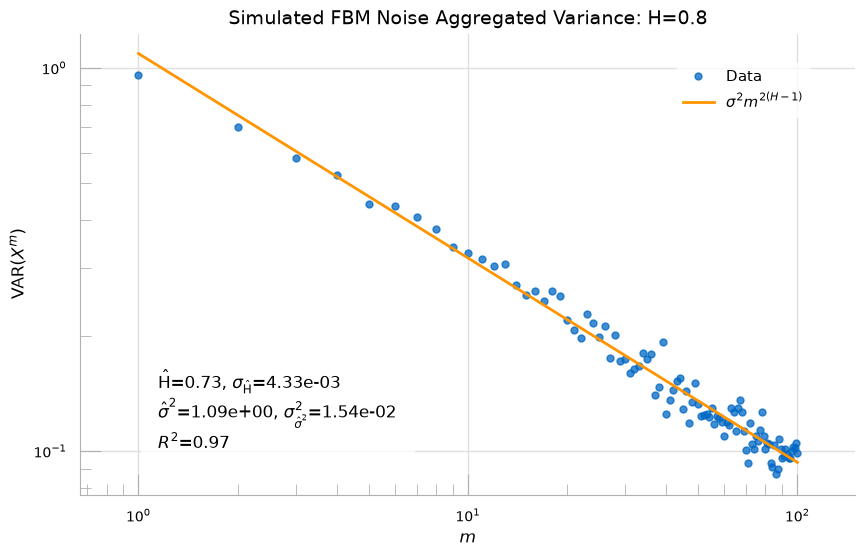

In [8]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

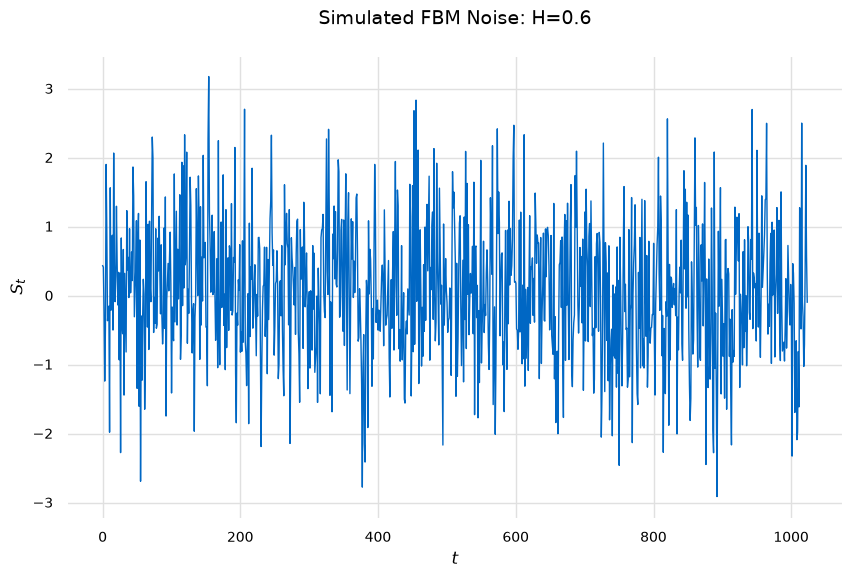

In [9]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

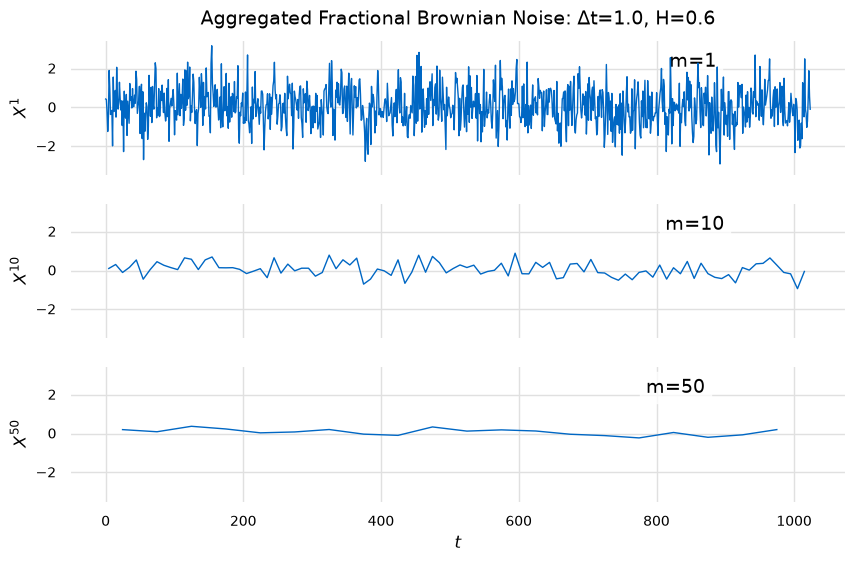

In [10]:
var_agg_comparison(t, fbm_noise, H)

In [11]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [12]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2062.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.24e-67
Time:                        13:39:52   Log-Likelihood:                 115.91
No. Observations:                 100   AIC:                            -227.8
Df Residuals:                      98   BIC:                            -222.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0096      0.031     -0.308      0.759      -0.071       0.052
x1            -0.8685      0.019    -45.414      0.000      -0.906      -0.831
==============================================================================
Omnibus:                        0.607   Durbin-Watson:                   0.993
Prob(Omnibus):                  0.738   Jarque-Bera (JB):                0.676
Skew:                          -0.178   Prob(JB):                        0.713
Kurtosis:                       2.811   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.009607105252069523,
      "err": 0.031170163257256304,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9e1276b0-4b88-4e3d-92d4-92e39316549b",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.868538555492661,
         "err": 0.019125046540333687,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "9e1276b0-4b88-4e3d-92d4-92e39316549b",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9546380601870713,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9e1276b0-4b88-4e3d-92d4-92e39316549b",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param

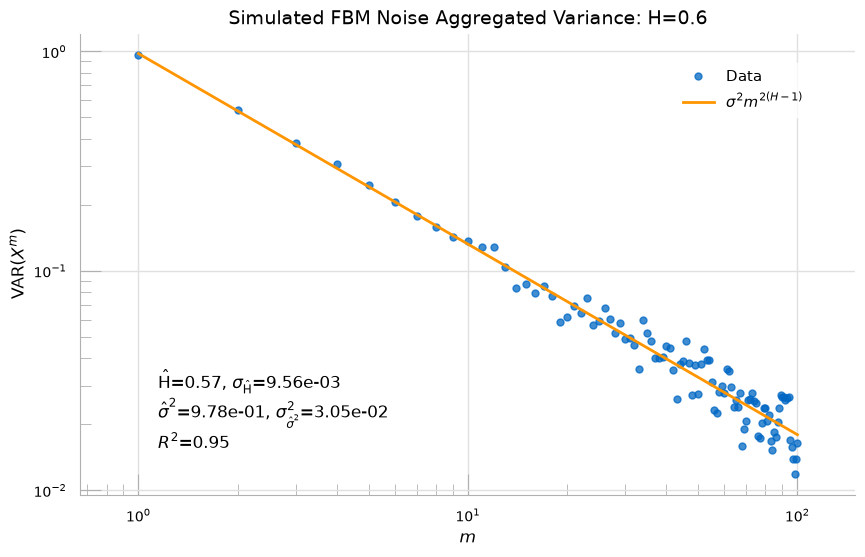

In [14]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

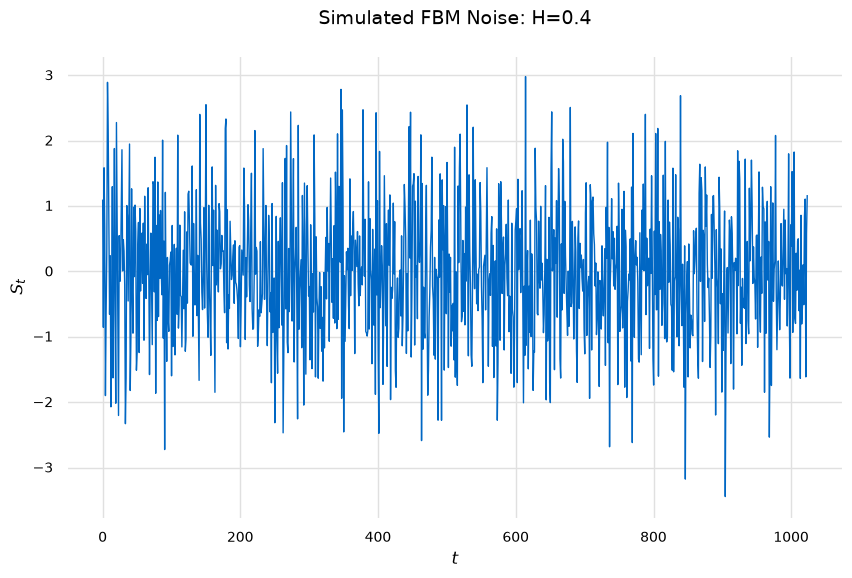

In [15]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

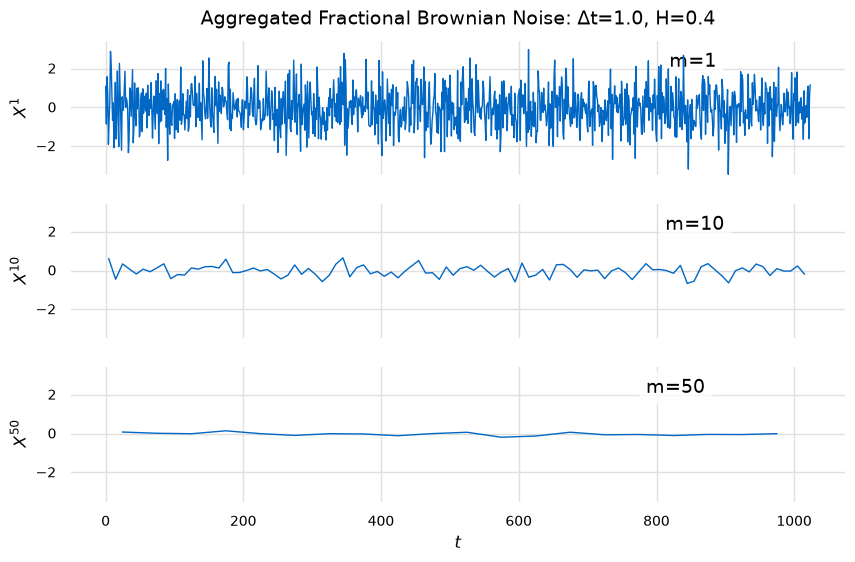

In [16]:
var_agg_comparison(t, fbm_noise, H)

In [17]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [18]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1934.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           2.51e-66
Time:                        13:39:53   Log-Likelihood:                 73.996
No. Observations:                 100   AIC:                            -144.0
Df Residuals:                      98   BIC:                            -138.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1644      0.047      3.468      0.001       0.070       0.258
x1            -1.2788      0.029    -43.975      0.000      -1.337      -1.221
==============================================================================
Omnibus:                        0.856   Durbin-Watson:                   0.981
Prob(Omnibus):                  0.652   Jarque-Bera (JB):                0.823
Skew:                          -0.214   Prob(JB):                        0.663
Kurtosis:                       2.884   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.16436827539441873,
      "err": 0.047396844452006294,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "6d73145e-eb2f-46b9-baf7-212af53c2bf5",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.2788346967522235,
         "err": 0.029081235427875236,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "6d73145e-eb2f-46b9-baf7-212af53c2bf5",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9517660141749957,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "6d73145e-eb2f-46b9-baf7-212af53c2bf5",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param"

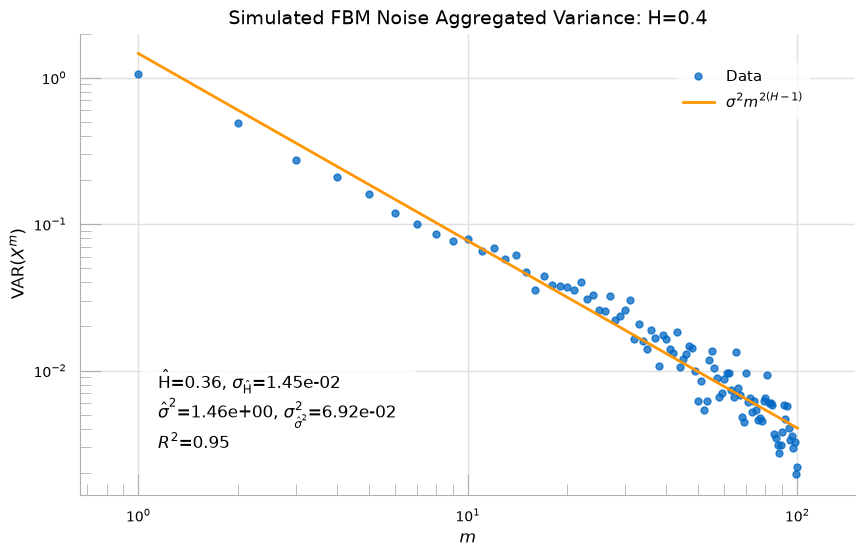

In [20]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

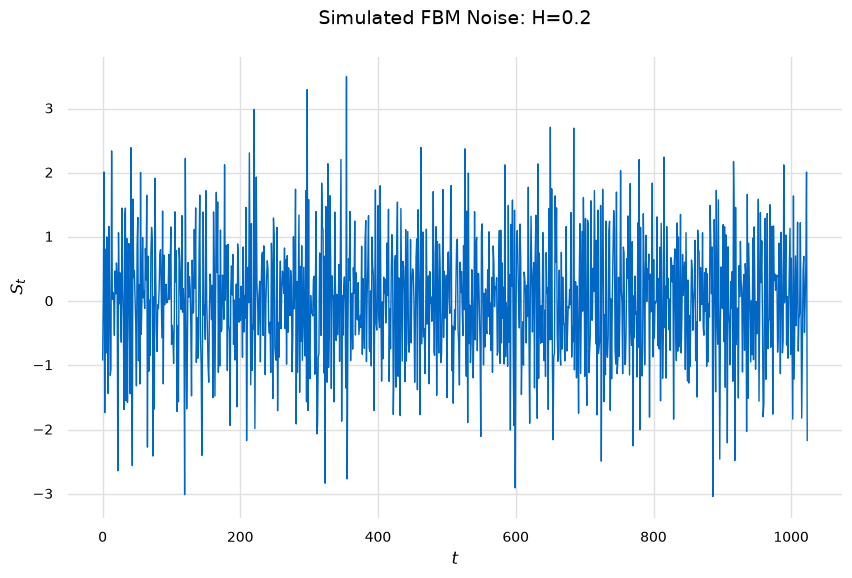

In [21]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

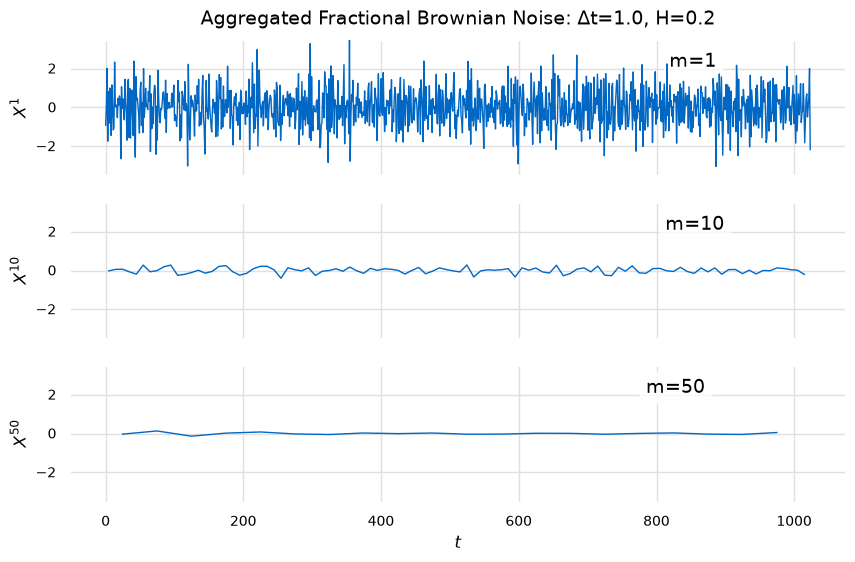

In [22]:
var_agg_comparison(t, fbm_noise, H)

In [23]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [24]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     1521.
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.75e-61
Time:                        13:39:53   Log-Likelihood:                 31.427
No. Observations:                 100   AIC:                            -58.85
Df Residuals:                      98   BIC:                            -53.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1584      0.073      2.184      0.031       0.014       0.302
x1            -1.7357      0.045    -38.994      0.000      -1.824      -1.647
==============================================================================
Omnibus:                        5.462   Durbin-Watson:                   1.406
Prob(Omnibus):                  0.065   Jarque-Bera (JB):                5.125
Skew:                          -0.397   Prob(JB):                       0.0771
Kurtosis:                       3.774   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.15843067547854384,
      "err": 0.07254802235005665,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "3a87e7e5-bf22-497a-ac19-4a1b189b246c",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.7357338627408143,
         "err": 0.04451321901661842,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "3a87e7e5-bf22-497a-ac19-4a1b189b246c",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.9394503497003166,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "3a87e7e5-bf22-497a-ac19-4a1b189b246c",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": 

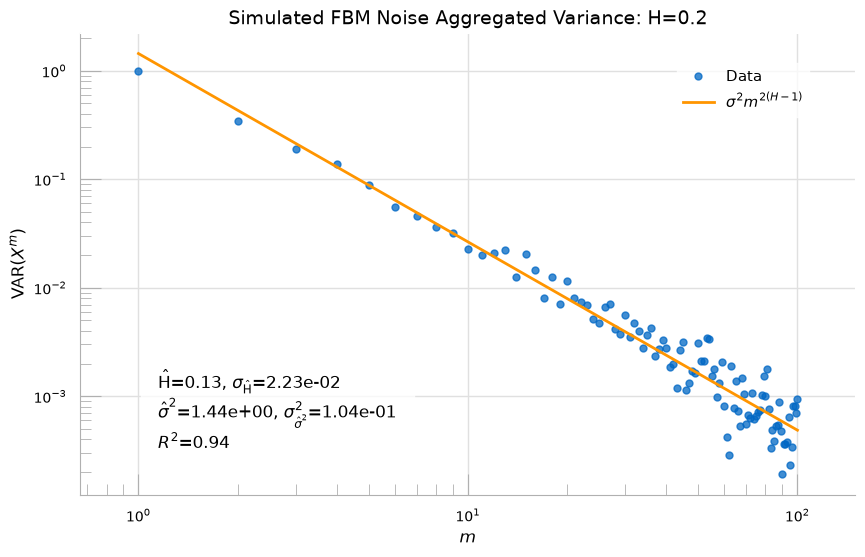

In [26]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")